# Fitting Matter-Pressure

## Setup (from demo)

In [1]:
import numpy as np
if not hasattr(np, "trapz"):
    np.trapz = np.trapezoid
import matplotlib.pyplot as plt
import pyccl as ccl
import os

In [2]:
class Pk(object):
    # Class to store power spectrum data
    def __init__(self, kmin, kmax, kavg, pk, nk):
        self.kmin = kmin
        self.kmax = kmax
        self.kavg = kavg
        self.pk = pk
        self.nk = nk

In [3]:
class SnapPk(object):
    Lbox = 1000.0  # Mpc Flamingo box size
    # Class to organise the power spectrum measurements in a given snapshot
    def __init__(self, namesim, snapnum, kmin=1e-2, kmax=1.0):
        self.sn = snapnum
        self.z = np.loadtxt("FLAMINGO/zs_list.txt")[snapnum]
        self.snapstr = '%04d' % self.sn
        self.sim = namesim
        self.kmin = kmin
        self.kmax = kmax
        self.predir = f'FLAMINGO/L1_m9/{self.sim}/power_spectra'

        # Read and rebin all power spectra
        self.pks = {f'{n1}_{n2}': self.read_pk(self.get_fname_pk(n1, n2))
                    for n1, n2 in self.iter_pairs()}

        # And estimate their Gaussian uncertainties
        self.epks = {f'{n1}_{n2}': self.get_pk_errors(n1, n2)
                     for n1, n2 in self.iter_pairs()}

    def get_pk_covar(self, na, nb, nc, nd):
        # Gaussian Pk covariance
        pkac = self.pks[f'{na}_{nc}'].pk
        pkad = self.pks[f'{na}_{nd}'].pk
        pkbc = self.pks[f'{nb}_{nc}'].pk
        pkbd = self.pks[f'{nb}_{nd}'].pk
        nk = self.pks[f'{na}_{nb}'].nk
        return (pkac*pkbd+pkad*pkbc)/nk

    def get_pk_errors(self, n1, n2):
        # Gaussian error bar
        pk11 = self.pks[f'{n1}_{n1}'].pk
        pk12 = self.pks[f'{n1}_{n2}'].pk
        pk22 = self.pks[f'{n2}_{n2}'].pk
        nk = self.pks[f'{n1}_{n2}'].nk
        return np.sqrt((pk11*pk22+pk12**2)/nk)

    def iter_pairs(self):
        # Returns all pairs of fields (including auto-correlations)
        for n1 in ['matter', 'pressure']:
            for n2 in ['matter', 'pressure']:
                yield n1, n2

    def iter_pairs_unique(self):
        # Returns unique pairs of fields (including auto-correlations)
        names = ['matter', 'pressure']
        for i, n1 in enumerate(names):
            for n2 in names[i:]:
                yield n1, n2

    def get_fname_pk(self, n1, n2):
        # Returns the filename of the power spectrum for a given pair of fields
        if n1 == n2:
            fname1 = fname2 = f'{self.predir}/power_{n1}_{self.snapstr}.txt'
        else:
            fname1 = f'{self.predir}/power_{n1}-{n2}_{self.snapstr}.txt'
            fname2 = f'{self.predir}/power_{n2}-{n1}_{self.snapstr}.txt'

        for fname in [fname1, fname2]:
            if os.path.isfile(fname):
                return fname
        raise KeyError(f'Unknown power spectrum {n1}-{n2}, {fname1}, {fname2}')

    def read_pk(self, fname_pk):
        # Reads a P(k) file in Sara's format and rebins it
        # to a common binning scheme
        d = np.loadtxt(fname_pk, unpack=True)
        ks = d[1]
        pk = d[2]
        # Impose scale cuts
        goodk = (ks >= self.kmin) & (ks <= self.kmax)
        ks = ks[goodk]
        pk = pk[goodk]
        dlk = np.diff(np.log(ks), append=np.log(ks[-1]**2/ks[-2]))
        kmin = np.exp(np.log(ks)-dlk/2)
        kmax = np.exp(np.log(ks)+dlk/2)
        kavg = ks
        nk = (self.Lbox*ks)**3*dlk/(2*np.pi**2)
        return Pk(kmin, kmax, kavg, pk, nk)

## Plotting 

In [4]:
snpk = SnapPk('L1_m9', 67, kmax=10)

In [5]:
# Create a cosmology object with the same parameters as Flamingo
cosmo = ccl.Cosmology(h=0.681, Omega_b=0.0486, Omega_c=0.306-0.0486, n_s=0.967, sigma8=0.807)

In [6]:
# Initialise the Eulerian PT calculator.
# Check out the documentation in https://ccl.readthedocs.io/en/latest/api/pyccl.nl_pt.ept.html
# to see the meaning of all parameters.
# We may want to play around with e.g. b1_pk_kind and sub_lowk, for example.
ept = ccl.nl_pt.EulerianPTCalculator(with_NC=True, sub_lowk=False, b1_pk_kind='pt', bk2_pk_kind='linear')
ept.update_ingredients(cosmo)

In [7]:
# Generate power spectrum interpolators for the different
# EFT templates.
pairs = ['b1:b1', 'b1:b2', 'b1:bs', 'b1:bk2', 'b2:b2', 'b2:bs', 'bs:bs']
pk2d_templates = {pair: ept.get_pk2d_template(pair) for pair in pairs}

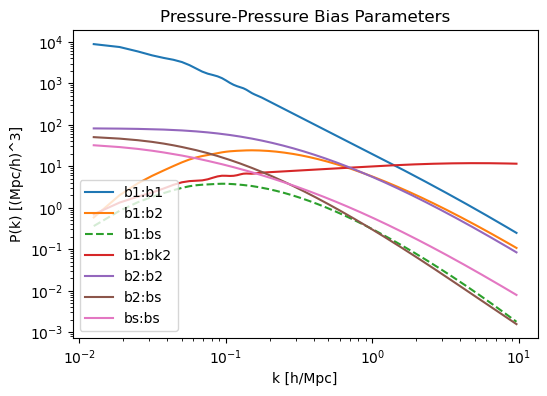

In [8]:
# Evaluate them and plot them
z = snpk.z
a = 1/(1+z)
k = snpk.pks['matter_pressure'].kavg
plt.figure(figsize=(6, 4))
plt.title('Pressure-Pressure Bias Parameters')
plt.plot(k, pk2d_templates['b1:b1'](k, a), label='b1:b1')
plt.plot(k, pk2d_templates['b1:b2'](k, a), label='b1:b2')
plt.plot(k, -pk2d_templates['b1:bs'](k, a), '--', label='b1:bs')
plt.plot(k, pk2d_templates['b1:bk2'](k, a), label='b1:bk2')
plt.plot(k, pk2d_templates['b2:b2'](k, a), label='b2:b2')
plt.plot(k, pk2d_templates['b2:bs'](k, a), label='b2:bs')
plt.plot(k, pk2d_templates['bs:bs'](k, a), label='bs:bs')
plt.loglog()
plt.xlabel('k [h/Mpc]')
plt.ylabel('P(k) [(Mpc/h)^3]')
plt.legend()

## Fitting Machinery (from demo)

In [9]:
from scipy.optimize import curve_fit

def plot_fit(k, pkd, epk, biases, templates):
    pkfit = np.dot(templates, biases)
    fig, axes = plt.subplot_mosaic(
        '''
        AAA
        AAA
        AAA
        BBB''', figsize=(6, 6), sharex=True)
    ax = axes['A']
    ax.errorbar(k, pkd, yerr=epk, label='data', fmt='o', markersize=3)
    ax.plot(k, pkfit, label='fit', color='red')
    for b, t, name in zip(biases, templates.T, ['b1:b1', 'b1:b2', 'b1:bs', 'b1:bk2', 'N']):
        if np.mean(b*t) < 0:
            tplot, ls = -t, '--'
        else:
            tplot, ls = t, '-'
        ax.plot(k, b*tplot, ls, label=name)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylabel('P(k) [(Mpc/h)^3]')
    ax.legend()
    ax = axes['B']
    ax.errorbar(k, (pkd-pkfit)/epk, yerr=1, fmt='o', markersize=3)
    ax.axhline(0, color='red', ls='--')
    ax.set_xscale('log')
    ax.set_ylabel(r'$\Delta P(k)/\sigma_P$')
    ax.set_xlabel('k [h/Mpc]')


def fit_pk(pk_data, pk_error, kmax=0.25, kmin=0.01, verbose=True, plot=True):
    # Fit a power spectrum with the EFT templates using curve_fit
    a = 1/(1+snpk.z)

    # Fit a power spectrum with the EFT templates
    k = pk_data.kavg
    pk = pk_data.pk
    epk = pk_error  # Gaussian error bars

    # Select the data to fit
    goodk = (k >= kmin) & (k <= kmax)
    kfit = k[goodk]
    pkfit = pk[goodk]
    epkfit = epk[goodk]

    tk_b1_b1 = pk2d_templates['b1:b1'](kfit, a)
    tk_b1_b2 = pk2d_templates['b1:b2'](kfit, a)
    tk_b1_bs = pk2d_templates['b1:bs'](kfit, a)
    tk_b1_bk2 = pk2d_templates['b1:bk2'](kfit, a)
    # Define the model function to fit
    def model(k, b1, b2, bs, bk2, N):
        return (b1 * tk_b1_b1 +
                0.5*b2 * tk_b1_b2 +
                0.5*bs * tk_b1_bs +
                0.5*bk2 * tk_b1_bk2 + N)

    # Fit the model to the data using least squares
    popt, pcov = curve_fit(model, kfit, pkfit, sigma=epkfit)
    chi2 = np.sum(((pkfit - model(kfit, *popt)) / epkfit) ** 2)
    ndof = len(pkfit) - len(popt)
    if verbose:
        print(f'Fit results: b1={popt[0]:.3e}, b2={popt[1]:.3e}, bs={popt[2]:.3e}, bk2={popt[3]:.3e}, N={popt[4]:.3e}, chi2/ndof={chi2/ndof:.2f}')
    if plot:
        Tmat = np.array([tk_b1_b1, 0.5*tk_b1_b2, 0.5*tk_b1_bs,
                         0.5*tk_b1_bk2, np.ones_like(tk_b1_b1)]).T
        plot_fit(kfit, pkfit, epkfit, popt, Tmat)
    return popt, pcov, chi2/ndof



def fit_pk_analytic(pk_data, pk_error, kmax=0.25, kmin=0.01, verbose=True, plot=True):
    # Fit a power spectrum with the EFT templates using the analytical least-squares solution
    a = 1/(1+snpk.z)

    # Fit a power spectrum with the EFT templates
    k = pk_data.kavg
    pk = pk_data.pk
    epk = pk_error  # Gaussian error bars

    # Select the data to fit
    goodk = (k >= kmin) & (k <= kmax)
    kfit = k[goodk]
    pkfit = pk[goodk]
    epkfit = epk[goodk]

    tk_b1_b1 = pk2d_templates['b1:b1'](kfit, a)
    tk_b1_b2 = pk2d_templates['b1:b2'](kfit, a)
    tk_b1_bs = pk2d_templates['b1:bs'](kfit, a)
    tk_b1_bk2 = pk2d_templates['b1:bk2'](kfit, a)
    
    tk_N = np.ones_like(tk_b1_b1)
    Tmat = np.array([tk_b1_b1, 0.5*tk_b1_b2, 0.5*tk_b1_bs, 0.5*tk_b1_bk2, tk_N]).T
    Cov = np.diag(epkfit**2)
    iCov = np.linalg.inv(Cov)
    TiCT = np.dot(Tmat.T, np.dot(iCov, Tmat))
    TiCp = np.dot(Tmat.T, np.dot(iCov, pkfit))
    pcov = np.linalg.inv(TiCT)
    popt = np.dot(pcov, TiCp)
    chi2 = np.sum(((pkfit - np.dot(Tmat, popt)) / epkfit) ** 2)
    ndof = len(pkfit) - len(popt)
    if verbose:
        print(f'Fit results: b1={popt[0]:.3e}, b2={popt[1]:.3e}, bs={popt[2]:.3e}, bk2={popt[3]:.3}, N={popt[4]:.3e}, chi2/ndof={chi2/ndof:.2f}')
    if plot:
        plot_fit(kfit, pkfit, epkfit, popt, Tmat)
    return popt, pcov, chi2/ndof

## Testing fit

Fit results: b1=7.983e-06, b2=-1.376e-04, bs=-8.153e-04, bk2=-5.29e-05, N=1.520e-03, chi2/ndof=0.73
Fit results: b1=7.983e-06, b2=-1.376e-04, bs=-8.153e-04, bk2=-5.287e-05, N=1.520e-03, chi2/ndof=0.73


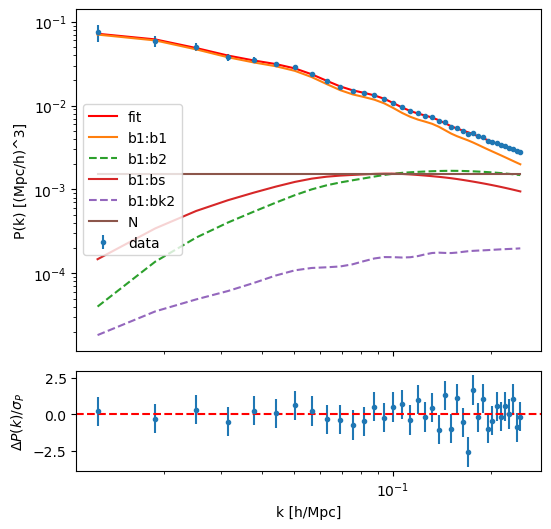

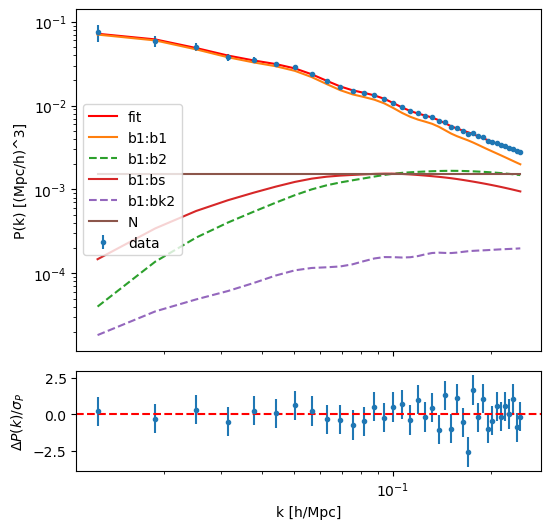

In [12]:
b_bf_ana, b_cov_ana = fit_pk_analytic(snpk.pks['matter_pressure'], snpk.epks['matter_pressure'], kmax=0.25, kmin=0.01)[:2]
b_bf, b_cov = fit_pk(snpk.pks['matter_pressure'], snpk.epks['matter_pressure'], kmax=0.25, kmin=0.01)[:2]

## Increasing kmax and adjusting redshift

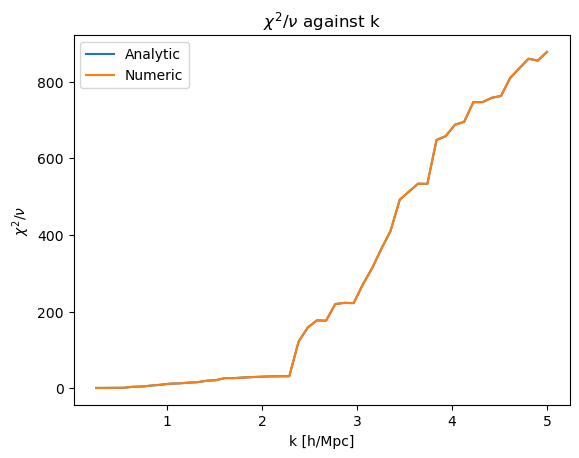

In [13]:
kmaxes = np.linspace(0.25, 5)#Plotting for a range of kmax

fig, axes = plt.subplots()
axes.set_ylabel(r'$\chi^2/\nu$')
axes.set_xlabel('k [h/Mpc]')
plt.title(r'$\chi^2/\nu$ against k' )

axes.plot(kmaxes, [fit_pk_analytic(snpk.pks['matter_pressure'], snpk.epks['matter_pressure'], kmax, kmin=0.01, verbose = False, plot = False)[2] for kmax in kmaxes], label = 'Analytic')
axes.plot(kmaxes, [fit_pk(snpk.pks['matter_pressure'], snpk.epks['matter_pressure'], kmax, kmin=0.01, verbose = False, plot = False)[2] for kmax in kmaxes], label = 'Numeric')
axes.legend();

/tmp/ipykernel_17039/3266106401.py:36: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt((pk11*pk22+pk12**2)/nk)


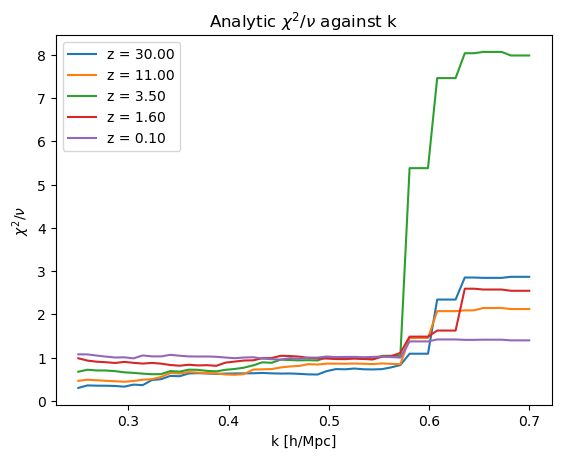

In [19]:
sample_indx = [0,30,60,90,120]
sample_snapshots = [SnapPk('L1_m9', r, kmax=10) for r in sample_indx]#Taking a few redshifts and looking at how the rate of deterioration changes.

fig, axes = plt.subplots()
axes.set_ylabel(r'$\chi^2/\nu$')
axes.set_xlabel('k [h/Mpc]')
# axes.set_yscale('log')

kmaxes = np.linspace(0.25, 0.7)

for snpk in sample_snapshots:
    chi2_dof_r = [fit_pk_analytic(snpk.pks['matter_pressure'], snpk.epks['matter_pressure'], kmax, kmin=0.01, verbose = False, plot = False)[2] for kmax in kmaxes]
    axes.plot(kmaxes, chi2_dof_r, label = f'z = {snpk.z:.2f}')
axes.legend()
plt.title(r'Analytic $\chi^2/\nu$ against k');

/tmp/ipykernel_17039/3266106401.py:36: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt((pk11*pk22+pk12**2)/nk)


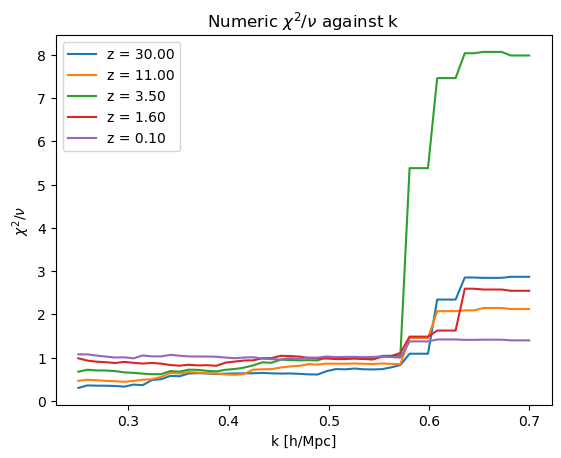

In [17]:
sample_indx = [0,30,60,90,120]
sample_snapshots = [SnapPk('L1_m9', r, kmax=10) for r in sample_indx]

fig, axes = plt.subplots()
axes.set_ylabel(r'$\chi^2/\nu$')
axes.set_xlabel('k [h/Mpc]')
# axes.set_yscale('log')

kmaxes = np.linspace(0.25, 0.7)

for snpk in sample_snapshots:
    chi2_dof_r = [fit_pk(snpk.pks['matter_pressure'], snpk.epks['matter_pressure'], kmax, kmin=0.01, verbose = False, plot = False)[2] for kmax in kmaxes]
    axes.plot(kmaxes, chi2_dof_r, label = f'z = {snpk.z:.2f}')
axes.legend()
plt.title(r'Numeric $\chi^2/\nu$ against k');

## Looking into z ~ 3.50 spike

/tmp/ipykernel_17039/3266106401.py:36: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt((pk11*pk22+pk12**2)/nk)


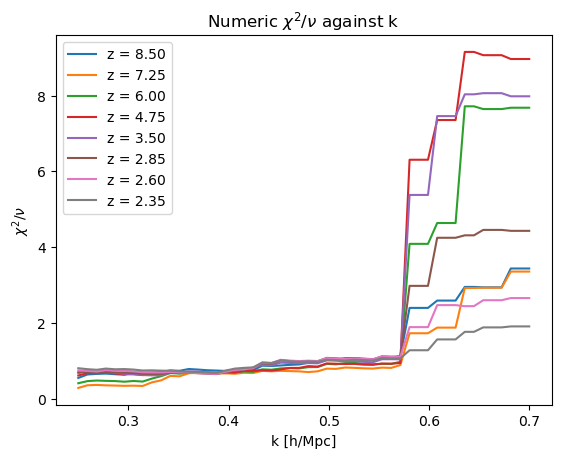

In [23]:
sample_indx = [i for i in range(40,80,5)]
sample_snapshots = [SnapPk('L1_m9', r, kmax=10) for r in sample_indx]

fig, axes = plt.subplots()
axes.set_ylabel(r'$\chi^2/\nu$')
axes.set_xlabel('k [h/Mpc]')
# axes.set_yscale('log')

kmaxes = np.linspace(0.25, 0.7)

for snpk in sample_snapshots:
    chi2_dof_r = [fit_pk(snpk.pks['matter_pressure'], snpk.epks['matter_pressure'], kmax, kmin=0.01, verbose = False, plot = False)[2] for kmax in kmaxes]
    axes.plot(kmaxes, chi2_dof_r, label = f'z = {snpk.z:.2f}')
axes.legend()
plt.title(r'Numeric $\chi^2/\nu$ against k');

Let's look at the behaviour of the actual power spectra and bias parameters with respect to the simulations.

In [ ]:
sample_indx = [i for i in range(50,70,5)]
sample_snapshots = [SnapPk('L1_m9', r, kmax=10) for r in sample_indx]

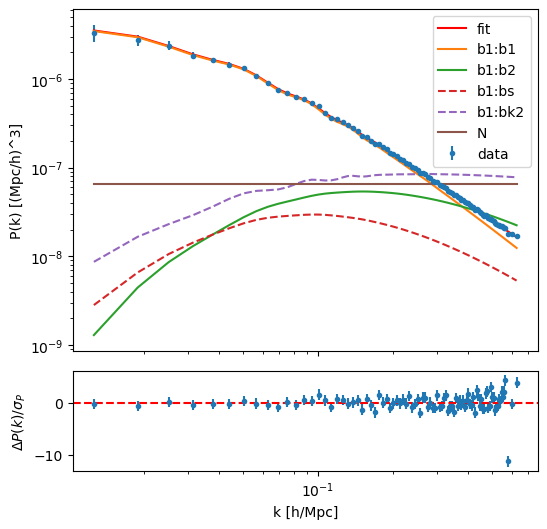

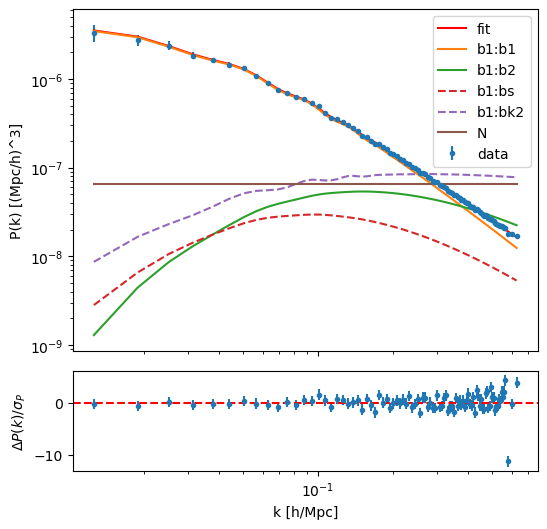

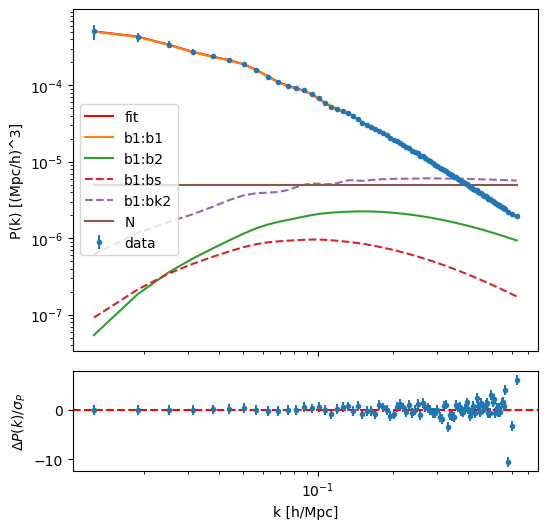

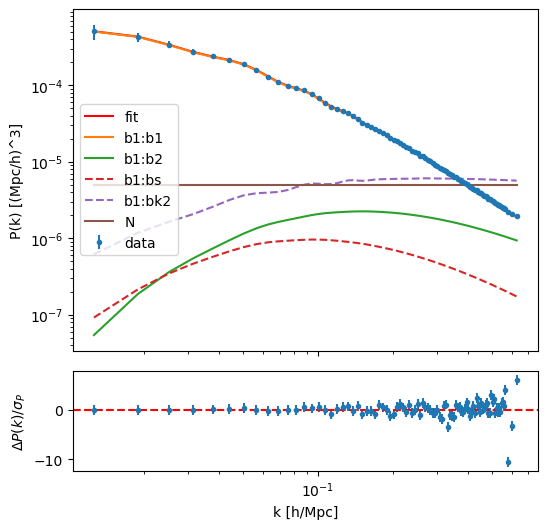

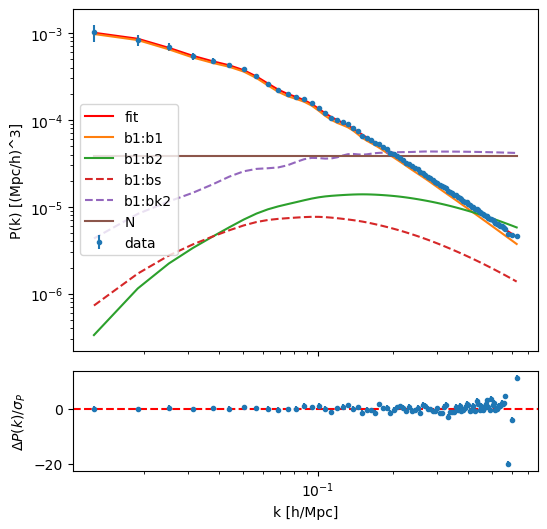

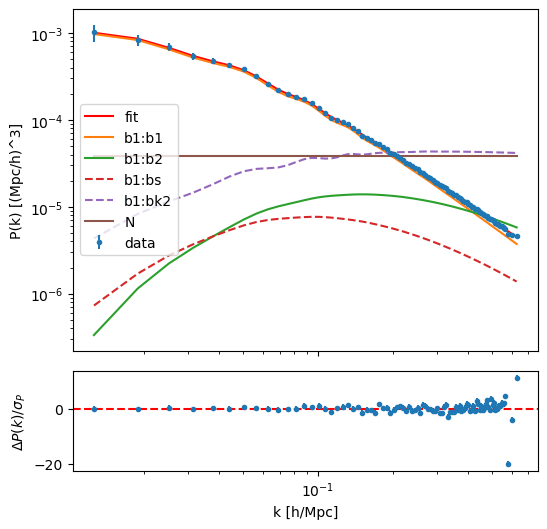

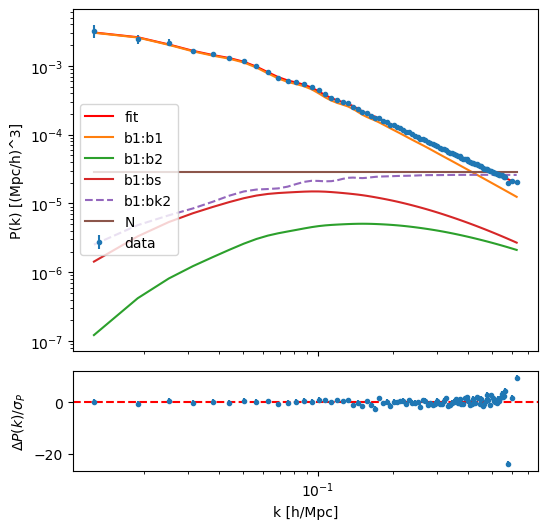

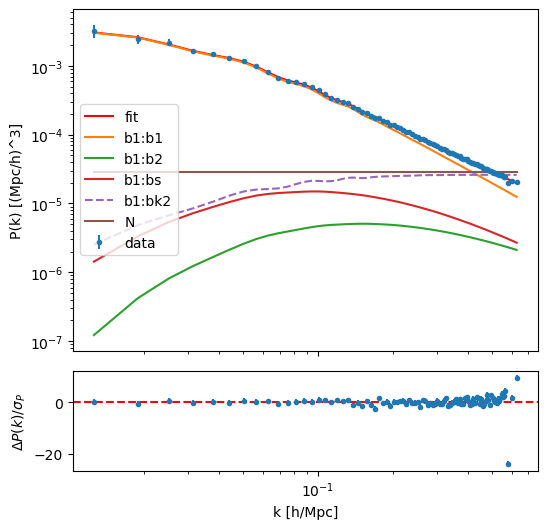

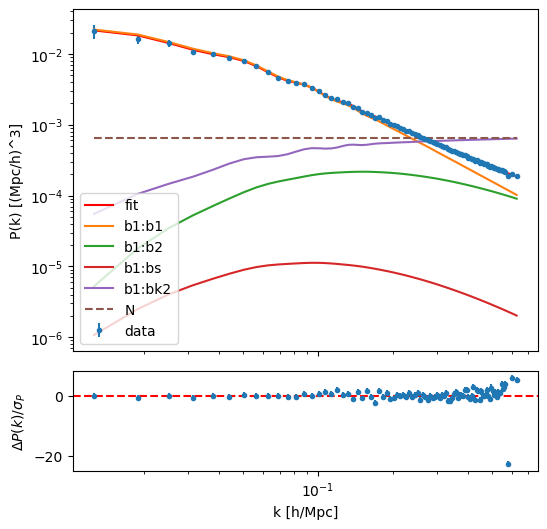

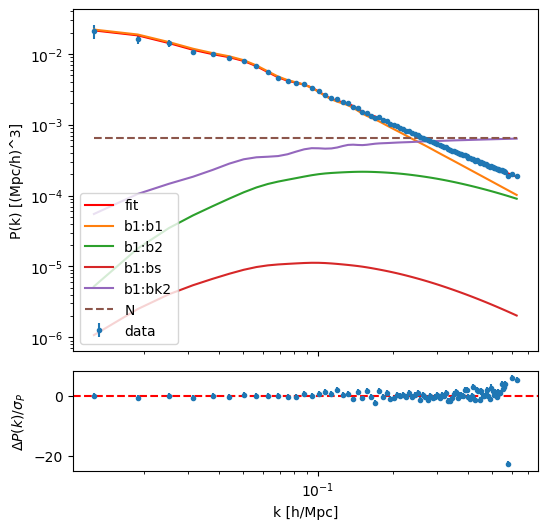

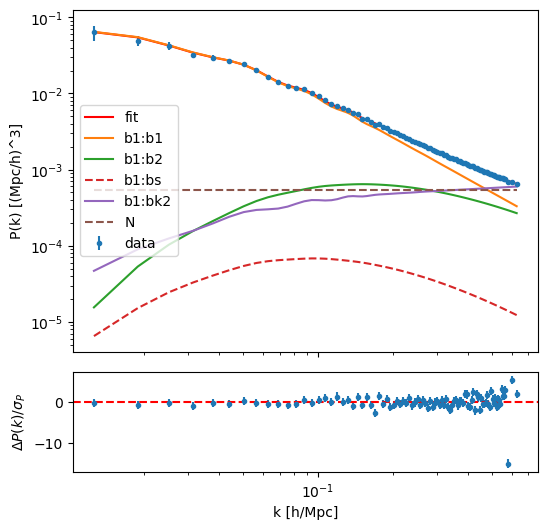

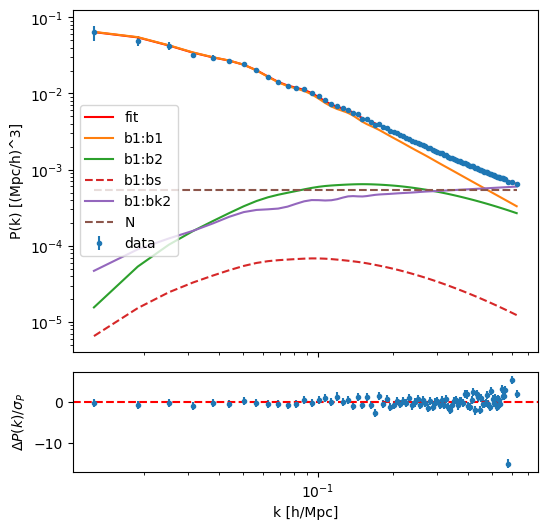

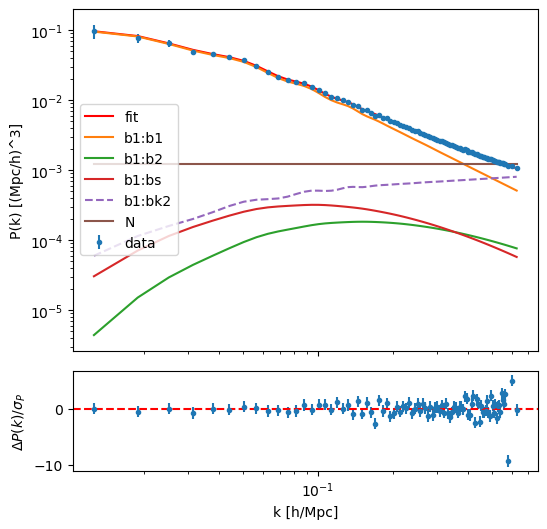

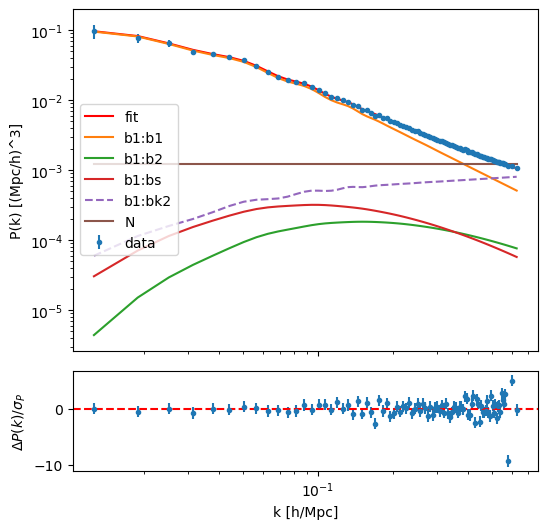

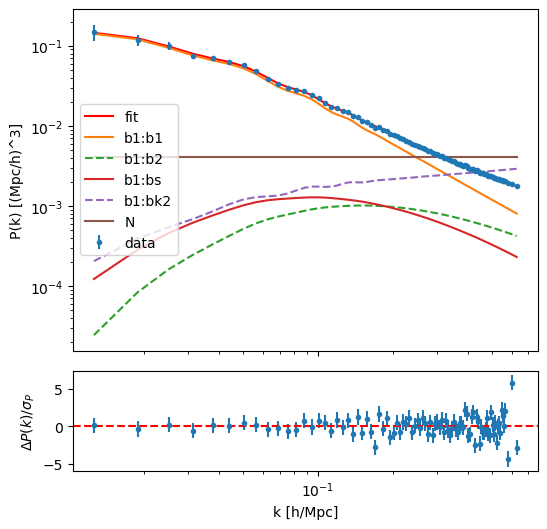

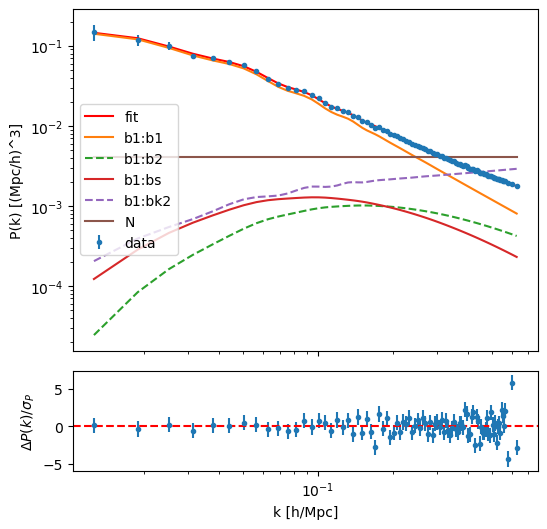

In [27]:
for snpk in sample_snapshots:
    
    b_bf_ana, b_cov_ana = fit_pk_analytic(snpk.pks['matter_pressure'], snpk.epks['matter_pressure'], kmax=0.65, kmin=0.01, verbose = False)[:2]
    b_bf, b_cov = fit_pk(snpk.pks['matter_pressure'], snpk.epks['matter_pressure'], kmax=0.65, kmin=0.01, verbose = False)[:2]